## Pathway enrichment (ORA)

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import scanpy as sc
import pandas as pd
import ma_codes as codes
from ma_codes import mysize, gray_red, mymap
import pertpy as pt
import seaborn as sns
from pathlib import Path
import math
import re
import gseapy as gp

try:
    from adjustText import adjust_text
    HAS_ADJUSTTEXT = True
except ImportError:
    HAS_ADJUSTTEXT = False

sc.settings.verbosity = 3               # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_version_and_date()

Running Scanpy 1.11.4, on 2026-08-13 12:02.


In [2]:
plt.rcParams['pdf.fonttype'] = 42

In [3]:
# Endothelial cells in endothelial compartments
dge_folder_mild   = "/media/synology/Huijuan/IPF_EC paper/snRNA_IPF_mild_severe/DGE_EC_celltype_MAST/DEG_IPF_Mild_Control/"
dge_folder_severe = "/media/synology/Huijuan/IPF_EC paper/snRNA_IPF_mild_severe/DGE_EC_celltype_MAST/DEG_IPF_Severe_Control/"

## gCap

In [4]:
cell_type_filename = "diffExpResults_gCap.xlsx"
out_base = "/media/synology/Huijuan/Plots/IPF_subsets/IPF_paper/MAST_EC_pathway/new/gCap/"

ct_label   = "gCap"
ct_color   = "#CAB2D6"
pval_thresh = 0.05
lfc_thresh  = 0.3
TOP_N_LABEL = 20
#GENE_SETS   = ['GO_Biological_Process_2025', 'Reactome_2022', 'MSigDB_Hallmark_2020']

In [5]:
# load DGE table
def load_dge(folder, fname):
    df = pd.read_excel(Path(folder) / fname)
    df = df.rename(columns={"Unnamed: 0": "gene"})
    return df

# Get up/down regulated gene list: p<0.05, |log2FC|>0.5
def get_up_down_genes(df, pval_col="p_val", lfc_col="avg_log2FC",
                       pval_thresh=0.05, lfc_thresh=0.5):
    sub = df.dropna(subset=[pval_col, lfc_col, "gene"])
    up = sub[(sub[pval_col] < pval_thresh) & (sub[lfc_col] > lfc_thresh)]["gene"].tolist()
    down = sub[(sub[pval_col] < pval_thresh) & (sub[lfc_col] < -lfc_thresh)]["gene"].tolist()
    return up, down

# pathway enrichment
def run_enrichr_up_down(glist_up, glist_down, outdir_up, outdir_down):
    enr_up = gp.enrichr(
        gene_list=glist_up,
        organism='Human',
        gene_sets=['GO_Biological_Process_2025', 'Reactome_2022', 'MSigDB_Hallmark_2020'],
        cutoff=0.05,  # p value
        outdir=outdir_up,
        no_plot=True,
    )
    enr_down = gp.enrichr(
        gene_list=glist_down,
        organism='Human',
        gene_sets=['GO_Biological_Process_2025', 'Reactome_2022', 'MSigDB_Hallmark_2020'],
        cutoff=0.05,
        outdir=outdir_down,
        no_plot=True,
    )
    return enr_up, enr_down

# load enrichment result
def load_results(outdir, gene_set):
    return pd.read_csv(Path(outdir) / f"{gene_set}.Human.enrichr.reports.txt", delimiter="\t")

# ── enrichment bar plot
def make_barplot(go_df, msig_df, go_idx, msig_idx, title, savepath=None,
                  figsize=(2, 3), palette="Reds"):
    go_sel = go_df.iloc[go_idx]
    msig_sel = msig_df.iloc[msig_idx]

    selection = pd.concat([msig_sel, go_sel], axis=0)
    selection["-log10(p_adj)"] = selection["Adjusted P-value"].apply(lambda x: -math.log10(x))
    selection.sort_values(by="-log10(p_adj)", ascending=False, inplace=True)

    fig, ax = plt.subplots()
    fig.set_size_inches(*figsize)
    sns.barplot(
        selection, x="-log10(p_adj)", y="Term", orient="y",
        hue="Gene_set", palette=palette,
        hue_order=["GO_Biological_Process_2025", "MSigDB_Hallmark_2020"]
    )
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    plt.title(title, loc='center')
    if savepath:
        plt.savefig(savepath, bbox_inches="tight")
    return fig, selection

# ── volcano plot ───────────────────────────────────────────────────────────────
def plot_volcano(
    df,
    condition,
    savepath=None,
    save=True,
    show=True,
    pval_col="p_val",
    lfc_col="avg_log2FC",
    figsize=(5, 4.5)
):
    df = df.dropna(subset=[pval_col, lfc_col, "gene"]).copy()

    df["-log10p"] = -np.log10(df[pval_col].clip(lower=1e-300))

    def status(r):
        if r[pval_col] < pval_thresh and r[lfc_col] > lfc_thresh:
            return "up"
        if r[pval_col] < pval_thresh and r[lfc_col] < -lfc_thresh:
            return "down"
        return "ns"

    df["status"] = df.apply(status, axis=1)

    n_up = (df["status"] == "up").sum()
    n_down = (df["status"] == "down").sum()

    color_map = {"up": ct_color, "down": "#4477AA", "ns": "#cccccc"}
    size_map = {"up": 18, "down": 18, "ns": 4}
    alpha_map = {"up": 0.85, "down": 0.85, "ns": 0.3}

    fig, ax = plt.subplots(figsize=figsize)

    for s in ["ns", "down", "up"]:
        sub = df[df["status"] == s]

        ax.scatter(
            sub[lfc_col],
            sub["-log10p"],
            s=size_map[s],
            c=color_map[s],
            alpha=alpha_map[s],
            linewidths=0,
            zorder=1 if s == "ns" else 3,
            rasterized=(s == "ns"),
        )

    ax.axhline(-np.log10(pval_thresh), color="#888888", lw=0.8, ls="--", zorder=2)
    ax.axvline(lfc_thresh, color="#888888", lw=0.8, ls="--", zorder=2)
    ax.axvline(-lfc_thresh, color="#888888", lw=0.8, ls="--", zorder=2)
    ax.axvline(0, color="#444444", lw=0.5, ls="-", zorder=2)

    top = pd.concat([
        df[df["status"] == "up"].nlargest(TOP_N_LABEL, "-log10p"),
        df[df["status"] == "down"].nlargest(TOP_N_LABEL, "-log10p"),
    ])

    texts = [
        ax.text(
            r[lfc_col],
            r["-log10p"],
            r["gene"],
            fontsize=6.5,
            color="#222222",
        )
        for _, r in top.iterrows()
    ]

    if HAS_ADJUSTTEXT:
        adjust_text(
            texts,
            ax=ax,
            arrowprops=dict(arrowstyle="-", color="#aaaaaa", lw=0.5),
        )

    xlim, ylim = ax.get_xlim(), ax.get_ylim()

    ax.text(
        xlim[1] * 0.97,
        ylim[1] * 0.97,
        f"Up: {n_up}",
        ha="right",
        va="top",
        fontsize=8,
        color=ct_color,
        fontweight="bold",
    )

    ax.text(
        xlim[0] * 0.97,
        ylim[1] * 0.97,
        f"Down: {n_down}",
        ha="left",
        va="top",
        fontsize=8,
        color="#4477AA",
        fontweight="bold",
    )

    ax.set_xlabel("log2 Fold Change", fontsize=10)
    ax.set_ylabel("–log10(p value)", fontsize=10)

    ax.set_title(
        f"{ct_label} — {condition}\n"
        f"threshold: p < {pval_thresh}, |log2FC| > {lfc_thresh}",
        fontsize=9,
        fontweight="bold",
    )

    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(labelsize=8)

    plt.tight_layout()

    if save:
        if savepath is None:
            raise ValueError("savepath must be provided when save=True")

        plt.savefig(savepath, bbox_inches="tight", dpi=300)
        print(f"  Saved: {Path(savepath).name}")

    if show:
        plt.show()

    plt.close(fig)

## Mild vs control

In [6]:
df_mild = load_dge(dge_folder_mild, cell_type_filename)
df_mild.head()

,gene,entrezgene,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,mean_IPF_Mild,mean_Control
0,XIST,7503.0,1.866587e-101,-0.152028,0.234,0.259,5.809751e-97,0.440911,0.479933
1,NAV3,89795.0,4.156858e-100,-1.992048,0.195,0.492,1.293822e-95,0.378367,1.040756
2,CD36,948.0,3.199569e-90,-6.091564,0.013,0.695,9.958658e-86,0.053506,1.565705
3,CSGALNACT1,55790.0,3.230832e-85,-3.473418,0.058,0.381,1.005596e-80,0.096686,0.757719
4,NRXN3,9369.0,7.573269e-78,-0.105547,0.509,0.597,2.357180e-73,1.419256,1.475259


In [7]:
glist_mild_up, glist_mild_down = get_up_down_genes(df_mild, pval_thresh=pval_thresh, lfc_thresh=lfc_thresh)
print(f"Mild vs Control DEGs— up: {len(glist_mild_up)}, down: {len(glist_mild_down)}")

Mild vs Control DEGs— up: 3827, down: 730


In [8]:
print(glist_mild_up)

['PTCHD4', 'COL4A2', 'JAG1', 'KIF13A', 'RAPGEF5', 'ITGA1', 'ENG', 'PRKCE', 'COL4A1', 'PLPP3', 'RGS5', 'EPB41L4A', 'PIK3R3', 'RGCC', 'NCKAP5', 'ANTXR1', 'GRK5', 'FENDRR', 'PLXNA2', 'SH3RF3', 'FCN3', 'PRICKLE2', 'FAT1', 'EMP1', 'CMTM8', 'LRP6', 'SMURF2', 'ZFHX3', 'ID1', 'HYAL2', 'PREX1', 'SMAD6', 'STXBP6', 'PDLIM1', 'ABHD17C', 'TGFBR1', 'AL353138.1', 'IL1RL1', 'PHLDA1', 'CRIM1', 'FRMD4A', 'SGK1', 'NREP', 'F2RL3', 'PRKX', 'AL499616.1', 'TMEM100', 'WWTR1', 'TCF4', 'MIR181A1HG', 'MAST2', 'THSD4', 'WARS', 'SLC26A2', 'ATP13A3', 'WSB1', 'LDB2', 'VIPR1', 'AL157392.3', 'RGS9', 'CDK17', 'DOCK6', 'BMP6', 'BCL2L14', 'MYO10', 'PLEKHG2', 'PCDH17', 'TMEM108', 'HECW2', 'IL4R', 'ABLIM1', 'STARD4-AS1', 'ARHGEF10', 'MPDZ', 'HLA-A', 'CCSER2', 'NEO1', 'ADCY4', 'ARRDC3', 'TJP2', 'SNRK', 'NAV1', 'COL4A5', 'TMCC3', 'RASIP1', 'TSPAN9', 'SEMA3G', 'IDO1', 'PODXL', 'PDE8A', 'MN1', 'AFF4', 'IL7R', 'AC119674.1', 'CLDN5', 'MT2A', 'COBLL1', 'ADAM19', 'KIF26B', 'KL', 'TRIM8', 'ZNF331', 'XKR6', 'THBD', 'NOVA2', 'SKIL', 

  Saved: volcano_gCap_mild_vs_control.pdf


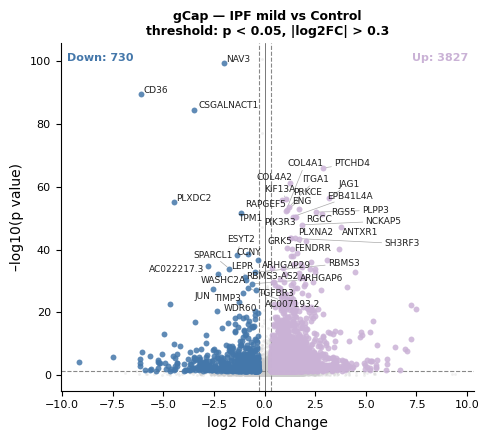

In [9]:
plot_volcano(df_mild, "IPF mild vs Control", save =True, show = True,
             savepath=out_base +"volcano_gCap_mild_vs_control.pdf")

In [10]:
enr_mild_up, enr_mild_down = run_enrichr_up_down(
    glist_mild_up, glist_mild_down,
    outdir_up=f"{out_base}/mild_up",
    outdir_down=f"{out_base}/mild_down",
)

### Upregulated pythways

In [11]:
GO_mild_up   = load_results(f"{out_base}/mild_up", "GO_Biological_Process_2025")
GO_mild_up.head(15)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2025,Proteasomal Protein Catabolic Process (GO:0010...,125/372,1.895045e-11,5.333259e-08,0,0,2.177125,53.75146,MIDN;UBE2D3;KEAP1;AUP1;DCAF1;PSMD4;PSMD1;FBXO6...
1,GO_Biological_Process_2025,Protein Ubiquitination (GO:0016567),124/369,2.269472e-11,5.333259e-08,0,0,2.177024,53.35643,UBE2D2;FBXO28;UBE2D3;KEAP1;RNF19B;FBXO22;UBE2L...
2,GO_Biological_Process_2025,Ubiquitin-Dependent Protein Catabolic Process ...,143/455,1.640122e-10,2.569524e-07,0,0,1.973297,44.46051,UBE2D2;UBE2D3;RNF19B;KEAP1;FBXO22;UBE2L3;DCAF1...
3,GO_Biological_Process_2025,Protein Modification by Small Protein Conjugat...,102/316,1.473167e-08,1.730971e-05,0,0,2.042047,36.82478,ZNF451;UBE2D2;UBE2D3;KEAP1;SMC5;UBE2L3;HERC3;R...
4,GO_Biological_Process_2025,Protein Polyubiquitination (GO:0000209),77/228,1.057885e-07,9.944123e-05,0,0,2.178709,34.99404,RNF14;UBE2D2;FBXO28;UBE2D3;FBXO22;UBE2L3;TRIM8...
5,GO_Biological_Process_2025,Proteasome-Mediated Ubiquitin-Dependent Protei...,103/340,4.271723e-07,3.346183e-04,0,0,1.859767,27.27549,UBE2D3;KEAP1;DCAF1;PSMD4;FBXO3;PSMD1;FBXO6;BTR...
6,GO_Biological_Process_2025,"Retrograde Vesicle-Mediated Transport, Golgi t...",24/47,8.682643e-07,5.829775e-04,0,0,4.431284,61.84641,ARF4;COPA;TMED10;KDELR1;PITPNB;STX18;COG3;UBE2...
7,GO_Biological_Process_2025,Response to Endoplasmic Reticulum Stress (GO:0...,65/196,2.050639e-06,1.116019e-03,0,0,2.115835,27.71185,GSK3B;CCDC47;FAF2;AUP1;SERP2;UFL1;SERP1;VSIG2;...
8,GO_Biological_Process_2025,Modification-Dependent Protein Catabolic Proce...,68/208,2.137058e-06,1.116019e-03,0,0,2.071683,27.04806,RNF11;RNF13;RNF14;UBE2D2;UBE2D3;KEAP1;RNF19B;A...
9,GO_Biological_Process_2025,Gene Expression (GO:0010467),109/381,4.101983e-06,1.927932e-03,0,0,1.713849,21.25866,ISCA1;RPL32;RPL34;EIF4A3;ADARB1;RPL8;RPL10A;PW...


In [12]:
Msig_mild_up = load_results(f"{out_base}/mild_up", "MSigDB_Hallmark_2020")
Msig_mild_up.head(15)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,MSigDB_Hallmark_2020,TGF-beta Signaling,31/54,5.027907e-10,2.513953e-08,0,0,5.734297,122.776200,BCAR3;BMPR2;SLC20A1;HDAC1;UBE2D3;XIAP;FURIN;FN...
1,MSigDB_Hallmark_2020,Oxidative Phosphorylation,73/200,5.802748e-09,1.450687e-07,0,0,2.456924,46.595400,ISCA1;SLC25A3;MRPS11;ETFA;TCIRG1;PHB2;OPA1;TIM...
2,MSigDB_Hallmark_2020,Interferon Gamma Response,62/200,3.717674e-05,6.196123e-04,0,0,1.913448,19.516840,IFITM3;OGFR;RTP4;CD40;IFITM2;SPPL2A;ADAR;IFI35...
3,MSigDB_Hallmark_2020,Myc Targets V1,59/200,2.551600e-04,3.189500e-03,0,0,1.780368,14.730090,SLC25A3;RPL34;RPLP0;PWP1;PHB2;UBE2L3;SYNCRIP;Y...
4,MSigDB_Hallmark_2020,Protein Secretion,32/96,6.758679e-04,6.006889e-03,0,0,2.122398,15.492470,STX12;ARF1;TMED10;TSG101;COPB1;GOSR2;CLTC;RAB2...
5,MSigDB_Hallmark_2020,p53 Pathway,57/200,8.225476e-04,6.006889e-03,0,0,1.694849,12.038690,RB1;APP;CSRNP2;CD81;DGKA;RNF19B;PITPNC1;SEC61A...
6,MSigDB_Hallmark_2020,PI3K/AKT/mTOR Signaling,34/105,8.409645e-04,6.006889e-03,0,0,2.032907,14.394940,ATF1;GSK3B;ARF1;CAB39;YWHAB;UBE2D3;CLTC;PTEN;P...
7,MSigDB_Hallmark_2020,DNA Repair,44/150,1.643348e-03,9.510106e-03,0,0,1.762971,11.302440,POM121;RALA;TSG101;CANT1;MPG;DCTN4;NT5C;DGUOK;...
8,MSigDB_Hallmark_2020,Unfolded Protein Response,35/113,1.711819e-03,9.510106e-03,0,0,1.904566,12.132470,FKBP14;GOSR2;EIF4A3;CEBPG;SDAD1;RPS14;SERP1;KI...
9,MSigDB_Hallmark_2020,TNF-alpha Signaling via NF-kB,55/200,2.418660e-03,1.209330e-02,0,0,1.611767,9.710159,B4GALT1;RNF19B;AREG;SLC2A6;ICAM1;IFIH1;PLAU;ZC...


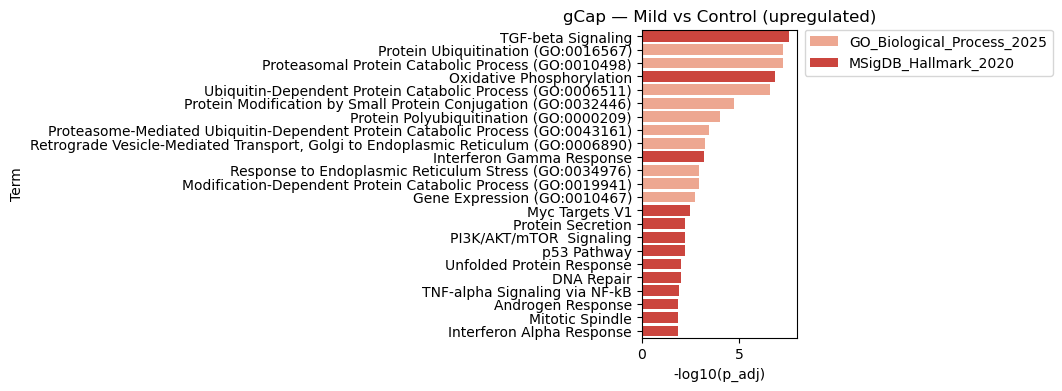

In [13]:
fig_mild_up, sel_mild_up = make_barplot(
    GO_mild_up, Msig_mild_up,
    go_idx=range(0, 10), msig_idx=range(0, 13),
    title="gCap — Mild vs Control (upregulated)",
    savepath=f"{out_base}/gCap_mild_up.pdf",
    figsize=(2, 4)
)

### Downregulated pathways

In [14]:
GO_mild_down   = load_results(f"{out_base}/mild_down", "GO_Biological_Process_2025")
GO_mild_down.head(15)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2025,Regulation of Stress Fiber Assembly (GO:0051492),11/75,0.000083,0.077088,0,0,4.591142,43.15141,TJP1;LIMCH1;TPM1;EVL;ARHGAP28;CD47;ARHGAP6;CGN...
1,GO_Biological_Process_2025,Antigen Processing and Presentation of Exogeno...,7/31,0.000102,0.077088,0,0,7.764062,71.31929,MFSD6;HLA-DRB5;IFI30;CTSS;HLA-DQA1;HLA-DQB2;HL...
2,GO_Biological_Process_2025,Peroxisome Proliferator Activated Receptor Sig...,4/8,0.000110,0.077088,0,0,26.537190,241.99100,NCOA1;NCOA2;PDK3;PPARG
3,GO_Biological_Process_2025,Negative Regulation of Cell Migration (GO:0030...,18/184,0.000144,0.077088,0,0,2.909435,25.73031,CD74;MCTP1;LIMCH1;SERPINE1;TPM1;ARID4A;STC1;NE...
4,GO_Biological_Process_2025,Negative Regulation of Stress Fiber Assembly (...,6/24,0.000177,0.077088,0,0,8.863720,76.55492,TJP1;ARHGAP28;ARHGAP6;CGNL1;CLASP1;CLASP2
5,GO_Biological_Process_2025,Regulation of Cellular Response to Insulin Sti...,4/9,0.000192,0.077088,0,0,21.228650,181.72740,NCOA1;NCOA2;PPARG;ATP2B1
6,GO_Biological_Process_2025,"Regulation of mRNA Splicing, via Spliceosome (...",12/97,0.000213,0.077088,0,0,3.772243,31.89863,RBM39;KHDRBS2;RBM25;KHDRBS3;SON;TRA2B;TRA2A;CI...
7,GO_Biological_Process_2025,Antigen Processing and Presentation of Exogeno...,6/25,0.000226,0.077088,0,0,8.396772,70.47910,HLA-DRB5;IFI30;CTSS;HLA-DQA1;HLA-DQB2;HLA-DRB1
8,GO_Biological_Process_2025,Basement Membrane Organization (GO:0071711),4/10,0.000310,0.088053,0,0,17.689620,142.91340,HMCN1;NID1;NID2;CTSS
9,GO_Biological_Process_2025,Antigen Processing and Presentation of Peptide...,6/27,0.000355,0.088053,0,0,7.596290,60.33083,HLA-DRB5;IFI30;CTSS;HLA-DQA1;HLA-DQB2;HLA-DRB1


In [15]:
Msig_mild_down = load_results(f"{out_base}/mild_down", "MSigDB_Hallmark_2020")
Msig_mild_down.head(15)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,MSigDB_Hallmark_2020,Hypoxia,25/200,8.271834e-08,0.000004,0,0,3.869301,63.099880,PPP1R15A;ERRFI1;SCARB1;KDM3A;SERPINE1;STC1;ADM...
1,MSigDB_Hallmark_2020,UV Response Dn,15/144,2.557590e-04,0.006010,0,0,3.112864,25.747350,CAV1;SERPINE1;ATP2B1;SYNE1;TGFBR2;TGFBR3;TJP1;...
2,MSigDB_Hallmark_2020,TNF-alpha Signaling via NF-kB,18/200,4.044351e-04,0.006336,0,0,2.651438,20.715740,PPP1R15A;JUN;EDN1;GADD45B;TSC22D1;TIPARP;PLK2;...
3,MSigDB_Hallmark_2020,Apoptosis,15/161,8.381808e-04,0.009849,0,0,2.747964,19.467340,JUN;ANXA1;GADD45B;CAV1;HMGB2;HSPB1;NEDD9;DCN;T...
4,MSigDB_Hallmark_2020,Androgen Response,10/100,3.553813e-03,0.033406,0,0,2.959877,16.692920,TPD52;INPP4B;ABCC4;CDK6;TSC22D1;SCD;SELENOP;NG...
5,MSigDB_Hallmark_2020,Adipogenesis,15/200,6.779386e-03,0.045519,0,0,2.164241,10.807940,SCARB1;APLP2;EPHX2;GPHN;FABP4;SCP2;UBC;ENPP2;P...
6,MSigDB_Hallmark_2020,Epithelial Mesenchymal Transition,15/200,6.779386e-03,0.045519,0,0,2.164241,10.807940,JUN;ECM2;GADD45B;SERPINE1;TPM1;FN1;NID2;DCN;TG...
7,MSigDB_Hallmark_2020,Coagulation,11/138,1.240196e-02,0.072862,0,0,2.306057,10.123360,F8;ANXA1;SERPINE1;CFI;FN1;TIMP3;LTA4H;A2M;DUSP...
8,MSigDB_Hallmark_2020,Estrogen Response Early,14/200,1.529875e-02,0.079894,0,0,2.006187,8.385831,FARP1;SCARB1;TIPARP;ELOVL2;SLC1A1;SNX24;FOS;GA...
9,MSigDB_Hallmark_2020,Cholesterol Homeostasis,7/74,1.822515e-02,0.085658,0,0,2.774943,11.113510,ERRFI1;ADH4;FABP5;SCD;PDK3;PPARG;ATF3


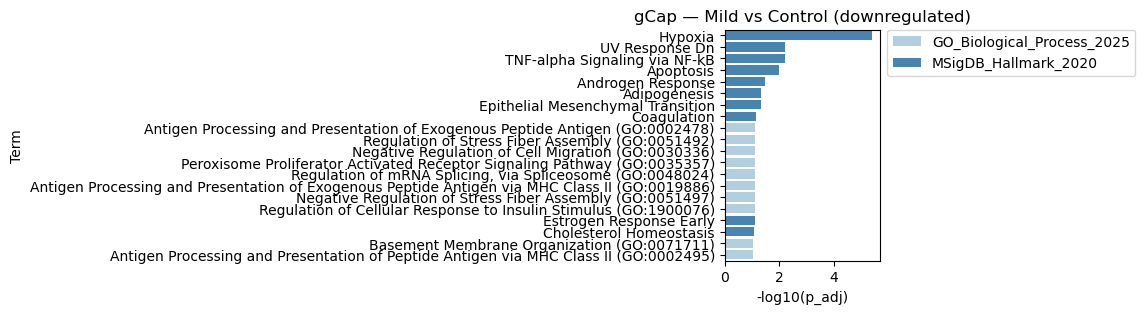

In [16]:
fig_mild_down, sel_mild_down = make_barplot(
    GO_mild_down, Msig_mild_down,
    go_idx=range(0, 10), msig_idx=range(0, 10),
    title="gCap — Mild vs Control (downregulated)",
    savepath=f"{out_base}/gCap_mild_down.pdf",
    palette="Blues",
)

## Severe vs control

In [17]:
df_severe = load_dge(dge_folder_severe, cell_type_filename)
df_severe.head()

,gene,entrezgene,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,mean_IPF_Severe,mean_Control
0,XIST,7503.0,4.484176e-17,0.204128,0.270,0.259,1.395700e-12,0.535030,0.479933
1,ADAMTS6,11174.0,6.465709e-14,1.128738,0.475,0.282,2.012452e-09,0.859720,0.484816
2,CRELD2,79174.0,7.979852e-14,1.434962,0.032,0.012,2.483729e-09,0.031983,0.012507
3,RASGRF2,5924.0,2.795914e-11,0.802061,0.365,0.201,8.702283e-07,0.585005,0.376400
4,ABLIM2,84448.0,1.946524e-10,4.119460,0.102,0.007,6.058556e-06,0.137586,0.008236


In [18]:
glist_severe_up, glist_severe_down = get_up_down_genes(df_severe, pval_thresh=pval_thresh, lfc_thresh=lfc_thresh)
print(f"Severe vs Control DEGs— up: {len(glist_severe_up)}, down: {len(glist_severe_down)}")

Severe vs Control DEGs— up: 887, down: 85


In [19]:
print(glist_severe_up)

['ADAMTS6', 'CRELD2', 'RASGRF2', 'ABLIM2', 'NRXN3', 'CYYR1', 'PIK3R3', 'RGCC', 'AC109927.1', 'LEF1', 'IGSF9B', 'PTCHD4', 'PTPRE', 'IFI16', 'DUSP18', 'ATP13A3', 'SWAP70', 'PDE4D', 'VMA21', 'PPP2CA', 'ID1', 'AC013287.1', 'AFF3', 'HOMER1', 'AC008050.1', 'CMIP', 'SLC22A4', 'RABGAP1', 'PITPNC1', 'AC087286.2', 'FAM222A', 'THSD4', 'ZMIZ2', 'CIP2A', 'CPNE5', 'MCTS1', 'MPPED2', 'ITSN1', 'AL353138.1', 'EXT2', 'MTFR1', 'FAM124A', 'CRIM1', 'CDK17', 'C20orf27', 'NLK', 'TSPAN13', 'RFTN1', 'DIPK2B', 'TET3', 'FUT8', 'NBEAL2', 'TULP4', 'KDM6A', 'ASXL1', 'ACACA', 'SGIP1', 'KIAA1549', 'MIR4435-2HG', 'PLPP1', 'ABLIM1', 'ZNF827', 'PCDH17', 'CCDC85A', 'BCKDHA', 'PLEKHG2', 'PRKAR2A', 'STX12', 'ATRAID', 'MECOM', 'UBE2F', 'LIX1-AS1', 'EBF4', 'CAMK2D', 'AC097376.3', 'SLC7A6OS', 'BTBD7', 'SMURF1', 'ZNF251', 'PPP5C', 'PKN3', 'CRMP1', 'AL356356.1', 'MYC', 'ZNF707', 'GNG12', 'AP1S1', 'AL583785.1', 'SH2B3', 'FOSL2', 'TCF12', 'AL596442.2', 'TTC33', 'TMEM219', 'SHC1', 'LINC02422', 'ZSWIM8', 'FLAD1', 'SNX25', 'NHSL1', 

  Saved: volcano_gCap_severe_vs_control.pdf


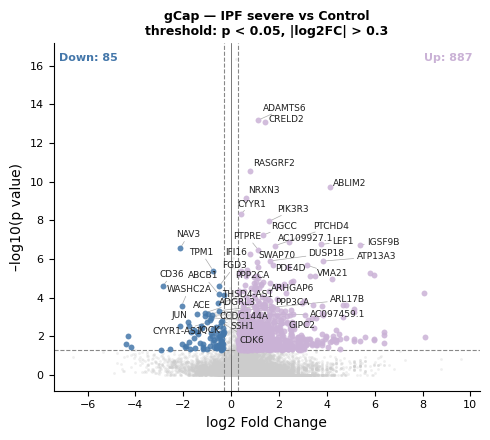

In [20]:
plot_volcano(df_severe, "IPF severe vs Control", save =True, show = True,
             savepath=out_base +"volcano_gCap_severe_vs_control.pdf")

In [ ]:
enr_severe_up, enr_severe_down = run_enrichr_up_down(
    glist_severe_up, glist_severe_down,
    outdir_up=f"{out_base}/severe_up",
    outdir_down=f"{out_base}/severe_down",
)

### Upregulated pathways

In [ ]:
GO_severe_up   = load_results(f"{out_base}/severe_up", "GO_Biological_Process_2025")
GO_severe_up.head(10)

In [ ]:
Msig_severe_up = load_results(f"{out_base}/severe_up", "MSigDB_Hallmark_2020")
Msig_severe_up.head(10)

In [ ]:
fig_severe_up, sel_severe_up = make_barplot(
    GO_severe_up, Msig_severe_up,
    go_idx=range(0, 10), msig_idx=range(0, 10),
    title="gCap — severe vs Control (upregulated)",
    savepath=f"{out_base}/gCap_severe_up.pdf",
)

### Downregulated pathways

In [ ]:
GO_severe_down   = load_results(f"{out_base}/severe_down", "GO_Biological_Process_2025")
GO_severe_down.head(15)

In [ ]:
Msig_severe_down = load_results(f"{out_base}/severe_down", "MSigDB_Hallmark_2020")
Msig_severe_down.head(10)

In [ ]:
fig_severe_down, sel_severe_down = make_barplot(
    GO_severe_down, Msig_severe_down,
    go_idx=range(0, 10), msig_idx=range(0, 3),
    title="gCap — severe vs Control (downregulated)",
    savepath=f"{out_base}/gCap_severe_down.pdf",
    palette="Blues",
)

In [ ]:
print(f"Mild vs Control — up: {len(glist_mild_up)}, down: {len(glist_mild_down)}")
print(f"Severe vs Control — up: {len(glist_severe_up)}, down: {len(glist_severe_down)}")

In [ ]:
print("Upregulated genes (Mild vs Control):")
print(glist_mild_up)

In [ ]:
print("Upregulated genes (Severe vs Control):")
print(glist_severe_up)

In [ ]:
from matplotlib_venn import venn2
mild_up = set(glist_mild_up)
severe_up = set(glist_severe_up)

overlap_genes = mild_up & severe_up

plt.figure(figsize=(4, 4))

venn2(
    [mild_up, severe_up],
    set_labels=("IPF mild", "IPF severe"),
    set_colors=("#4DBBD5", "#E64B35"),
    alpha=0.6,
)

plt.title("Overlap of upregulated genes")
plt.tight_layout()
plt.show()

print(f"Overlap genes: {len(overlap_genes)}")
print(sorted(overlap_genes))